# Exploratory Data Analysis
Answers research questions using 2022 as the primary reference year (most complete survey), with supplementary trend analysis for 2019-2024 and long-run history back to 1970.

| Section | Analyses |
|---|---|
| 1 | Income & poverty landscape |
| 2 | Health infrastructure per capita |
| 3 | Inequality & health correlation |
| 4 | Trends 2019-2024 |
| 5 | Long-run history 1970-2024 |
| 6 | Income Inequality Trend (Gini 1974–2022) |
| 7 | CPI & Real Income |

**Scope note:** W.P. Putrajaya is excluded from all analysis (administrative enclave, ~90 000 government-worker residents, not a general-purpose state). 
W.P. Kuala Lumpur is retained but flagged with * as an urban capital territory.

In [59]:
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import CLEAN
from scripts.transform import build_socioeconomic, build_population, build_health, build_combined
from scripts.visualise import (
    COLOR_MAP, EAST, HIGHLIGHT_STATES, HIGHLIGHT_COLORS,
    state_colors, legend_patches, save_fig, style_ax,
)

# Global style
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

In [60]:
combined = pd.read_csv(CLEAN / "combined_state.csv")
health   = pd.read_csv(CLEAN / "health_state.csv")
cpi      = pd.read_csv(CLEAN / "cpi_national.csv")

# Cross-sectional view: recent survey years merged with health data
df = combined[combined["year"].isin([2019, 2022, 2024])].merge(
    health, on=["state_code", "state", "year"], suffixes=("", "_hs")
)
df = df.drop(columns=[c for c in df.columns if c.endswith("_hs")])
df["region"] = df["state"].apply(lambda s: "East" if s in EAST else "West")

# Exclude W.P. Putrajaya from main analysis
df_main = df[df["territory_type"] != "admin"].copy()

# 2022 reference slice
ref = df_main[df_main.year == 2022].copy()

# Recent trends: excl. Putrajaya
se_main = combined[
    combined["year"].isin([2019, 2022, 2024]) &
    (combined["territory_type"] != "admin")
].copy()

# Historical series: excl. Putrajaya
hist_main = combined[combined["territory_type"] != "admin"].copy()

print(f"df_main shape: {df_main.shape}  (W.P. Putrajaya excluded)")
print(f"ref shape (2022): {ref.shape}")
print(f"cpi shape: {cpi.shape}  | years: {cpi['year'].min()}-{cpi['year'].max()}")
display(ref.head(3))

df_main shape: (45, 18)  (W.P. Putrajaya excluded)
ref shape (2022): (15, 18)
cpi shape: (66, 2)  | years: 1960-2025


,state_code,state,year,territory_type,income_mean,income_median,poverty_absolute,gini,cpi_overall,population,hospital_count,facility_count,beds_nonicu,beds_icu,beds_total,beds_per_1000,facilities_per_100k,region
1,JHR,Johor,2022,state,7529.730769,6215.346154,5.630769,0.366,127.233333,4028300.0,12,403,3276.0,95.0,3371.0,0.836829,10.004220,West
4,KDH,Kedah,2022,state,5442.600000,4349.266667,8.346667,0.359,127.233333,2163100.0,9,311,2685.0,81.0,2766.0,1.278720,14.377514,West
7,KTN,Kelantan,2022,state,4822.785714,3698.428571,13.485714,0.385,127.233333,1830600.0,10,271,2353.0,151.0,2504.0,1.367858,14.803889,West


---
## 1. Income & Poverty Landscape (2022)

> Which states have the highest and lowest household incomes?
> Which states carry the heaviest poverty burden?

In [61]:
# Rank states by mean income, then format values for a readable league table.
income_rank = (
    ref[["state", "income_mean", "income_median", "poverty_absolute", "territory_type"]]
    .sort_values("income_mean", ascending=False)
    .reset_index(drop=True)
)
income_rank.index += 1
income_rank.columns = ["State", "Mean income (RM)", "Median income (RM)", "Poverty rate (%)", "Type"]
income_rank[["Mean income (RM)", "Median income (RM)"]] = (
    income_rank[["Mean income (RM)", "Median income (RM)"]].round(0).astype(int)
)
income_rank["Poverty rate (%)"] = income_rank["Poverty rate (%)"].round(2)
display(income_rank) 

,State,Mean income (RM),Median income (RM),Poverty rate (%),Type
1,W.P. Kuala Lumpur,13118,10271,1.41,capital
2,Selangor,11359,9146,1.98,state
3,W.P. Labuan,8250,6904,2.50,island_ft
4,Pulau Pinang,8028,6426,2.10,state
5,Melaka,7877,6146,4.50,state
6,Johor,7530,6215,5.63,state
7,Terengganu,7111,5788,6.54,state
8,Negeri Sembilan,6047,4824,5.38,state
9,Sabah,5871,4446,21.82,state
10,Perlis,5625,4730,3.97,state


In [62]:
# Descriptive extremes using top/bottom-k selection.
top3_income  = ref.nlargest(3, "income_mean")["state"].tolist()
bot3_income  = ref.nsmallest(3, "income_mean")["state"].tolist()
top3_poverty = ref.nlargest(3, "poverty_absolute")["state"].tolist()
ratio = ref["income_mean"].max() / ref["income_mean"].min()

print(f"Highest income states : {top3_income}")
print(f"Lowest income states  : {bot3_income}")
print(f"Highest poverty states: {top3_poverty}")
print(f"Richest-to-poorest income ratio: {ratio:.1f}x")

# Two-sample t-test compares mean income between East and West groups.
east_inc = ref[ref.region == "East"]["income_mean"]
west_inc = ref[ref.region == "West"]["income_mean"]
t_stat, p_val = stats.ttest_ind(east_inc, west_inc)
print(f"\nEast vs West income t-test: t={t_stat:.3f}, p={p_val:.3f}")
print(f"Significant at alpha=0.05: {p_val < 0.05}")
# finding: no significant difference in mean income between East and West regions (p > 0.05)

Highest income states : ['W.P. Kuala Lumpur', 'Selangor', 'W.P. Labuan']
Lowest income states  : ['Kelantan', 'Sarawak', 'Kedah']
Highest poverty states: ['Sabah', 'Sarawak', 'Kelantan']
Richest-to-poorest income ratio: 2.7x

East vs West income t-test: t=-0.521, p=0.611
Significant at alpha=0.05: False


Saved fig1_income_ranking.png


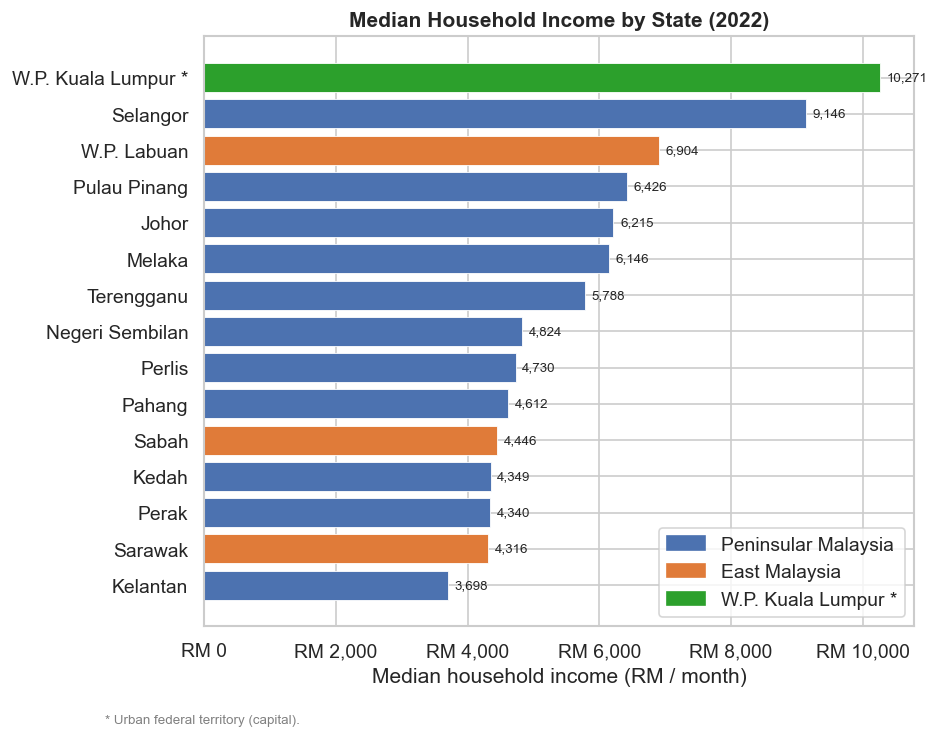

In [63]:
data = ref.sort_values("income_median", ascending=True).copy()
data["label"] = data["state"].apply(lambda s: f"{s} *" if s == "W.P. Kuala Lumpur" else s)
colors = state_colors(data["state"])

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(data.label, data.income_median, color=colors, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, data.income_median):
    ax.text(val + 100, bar.get_y() + bar.get_height() / 2, f"{val:,.0f}", va="center", fontsize=8)

ax.legend(handles=legend_patches(), loc="lower right")
fig.text(0.12, -0.02, "* Urban federal territory (capital).", fontsize=8, color="grey")
style_ax(ax, "Median Household Income by State (2022)",
         "Median household income (RM / month)", rm_format="x")

plt.tight_layout()
save_fig(fig, "fig1_income_ranking")
plt.show()

Saved fig2_poverty_ranking.png


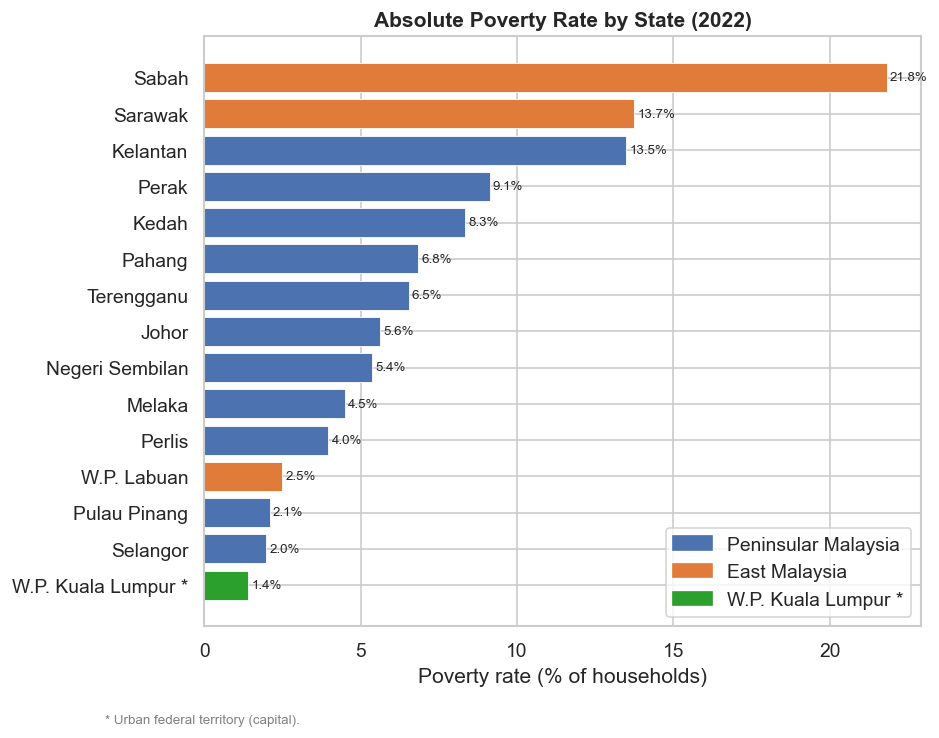

In [64]:
data = ref.sort_values("poverty_absolute", ascending=False).copy()
data["label"] = data["state"].apply(lambda s: f"{s} *" if s == "W.P. Kuala Lumpur" else s)
colors = state_colors(data["state"])

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(data.label, data.poverty_absolute, color=colors, edgecolor="white", linewidth=0.5)
ax.invert_yaxis()

for bar, val in zip(bars, data.poverty_absolute):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=8)

ax.legend(handles=legend_patches(), loc="lower right")
fig.text(0.12, -0.02, "* Urban federal territory (capital).", fontsize=8, color="grey")
style_ax(ax, "Absolute Poverty Rate by State (2022)", "Poverty rate (% of households)")

plt.tight_layout()
save_fig(fig, "fig2_poverty_ranking")
plt.show()

**Key finding:** The richest-to-poorest income ratio is 2.7x (W.P. Kuala Lumpur vs Kelantan). Poverty is most acute in Sabah (21.8%), Sarawak (13.7%), and Kelantan (13.5%) â€” all more than double the national average. The East vs West income gap is not statistically significant (t-test), indicating within-region dispersion drives inequality more than geography.

---
## 2. Health Infrastructure Per Capita (2022)

> Which states are best and worst served by public health resources?

Health Ranking: beds per 1 000 pop. as primary metric, then facilities per 100 k pop. and hospital count as tie-breakers


In [65]:
# Rank states by beds per capita (primary), while retaining tie-breaker metrics.
health_rank = (
    ref[["state", "beds_per_1000", "facilities_per_100k", "hospital_count"]]
    .sort_values("beds_per_1000", ascending=False)
    .reset_index(drop=True)
)
health_rank.index += 1
health_rank.columns = ["State", "Beds / 1 000 pop.", "Facilities / 100 k pop.", "Hospitals"]
health_rank["Beds / 1 000 pop."] = health_rank["Beds / 1 000 pop."].round(3)
health_rank["Facilities / 100 k pop."] = health_rank["Facilities / 100 k pop."].round(1)
display(health_rank)

,State,Beds / 1 000 pop.,Facilities / 100 k pop.,Hospitals
1,Perlis,1.767,14.1,1
2,Sarawak,1.526,11.9,23
3,Perak,1.389,14.6,16
4,Kelantan,1.368,14.8,10
5,Negeri Sembilan,1.359,14.1,8
6,Terengganu,1.325,16.5,6
7,Melaka,1.316,11.1,4
8,Kedah,1.279,14.4,9
9,W.P. Labuan,1.259,14.4,1
10,W.P. Kuala Lumpur,1.232,2.7,7


Health infrastructure by region (2022)



In [66]:
# Region-level means summarize typical public health capacity by geography.
display(ref.groupby("region")[["beds_per_1000", "facilities_per_100k"]].mean().round(3))

# Identify tails after dropping missing bed values for fair ranking.
best_beds = ref.dropna(subset=["beds_per_1000"]).nlargest(3, "beds_per_1000")["state"].tolist()
worst_beds = ref.nsmallest(3, "beds_per_1000")["state"].tolist()
print(f"\nBest-served (beds / 1 000) : {best_beds}")
print(f"Worst-served (beds / 1 000): {worst_beds}")

,beds_per_1000,facilities_per_100k
region,,
East,1.168,12.243
West,1.173,12.004



Best-served (beds / 1 000) : ['Perlis', 'Sarawak', 'Perak']
Worst-served (beds / 1 000): ['Selangor', 'Sabah', 'Johor']


Saved fig3_beds_ranking.png


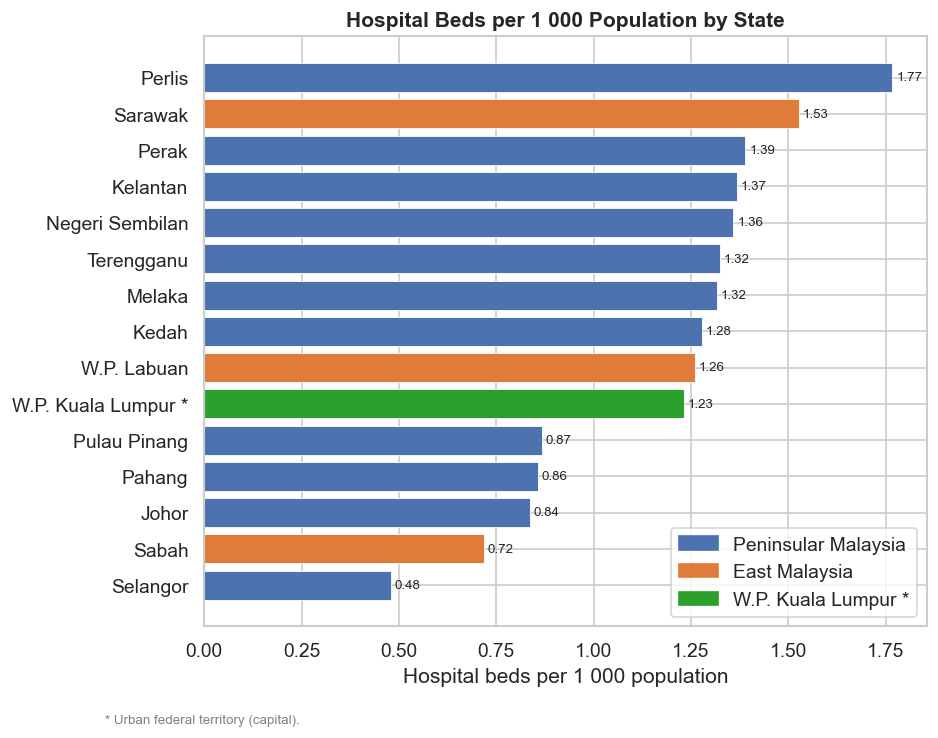

In [67]:
data = ref.sort_values("beds_per_1000", ascending=True).copy()
data["label"] = data["state"].apply(lambda s: f"{s} *" if s == "W.P. Kuala Lumpur" else s)
colors = state_colors(data["state"])

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(data.label, data.beds_per_1000, color=colors, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, data.beds_per_1000):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=8)

ax.legend(handles=legend_patches(), loc="lower right")
fig.text(0.12, -0.02, "* Urban federal territory (capital).", fontsize=8, color="grey")
style_ax(ax, "Hospital Beds per 1 000 Population by State", "Hospital beds per 1 000 population")

plt.tight_layout()
save_fig(fig, "fig3_beds_ranking")
plt.show()

**Key finding:** Perlis (1.77), Sarawak (1.53), and Perak (1.39) lead on beds per capita. Selangor (0.48) and Sabah (0.72) are the most underserved â€” counterintuitive because Selangor is Malaysia's second-richest state. This reflects the large private healthcare sector in urban areas that is not captured in MoH public data.

---
## 3. Inequality & Health Correlation (2022)

> Does income inequality or poverty rate predict fewer public health resources per capita?

In [68]:
# Pearson matrix captures pairwise linear associations across variables.
corr_cols = ["income_mean", "income_median", "poverty_absolute", "gini",
             "beds_per_1000", "facilities_per_100k"]
corr_matrix = ref[corr_cols].corr(method="pearson").round(3)
print("Pearson correlation matrix (2022):")
display(corr_matrix)

Pearson correlation matrix (2022):


,income_mean,income_median,poverty_absolute,gini,beds_per_1000,facilities_per_100k
income_mean,1.000,0.996,-0.603,0.042,-0.385,-0.784
income_median,0.996,1.000,-0.649,-0.035,-0.384,-0.752
poverty_absolute,-0.603,-0.649,1.000,0.454,-0.010,0.268
gini,0.042,-0.035,0.454,1.000,-0.086,-0.554
beds_per_1000,-0.385,-0.384,-0.010,-0.086,1.000,0.377
facilities_per_100k,-0.784,-0.752,0.268,-0.554,0.377,1.000


In [69]:
# Spearman tests monotonic relationships using ranks (less sensitive to outliers).
predictors = ["income_mean", "poverty_absolute", "gini"]
for outcome in ["beds_per_1000", "facilities_per_100k"]:
    print(f"Spearman correlations with {outcome}:")
    for col in predictors:
        mask = ref[col].notna() & ref[outcome].notna()
        r, p = stats.spearmanr(ref.loc[mask, col], ref.loc[mask, outcome])
        sig = "*" if p < 0.05 else ""
        print(f"  {col:<25}  r={r:+.3f}  p={p:.3f} {sig}")
    print()

Spearman correlations with beds_per_1000:
  income_mean                r=-0.532  p=0.041 *
  poverty_absolute           r=+0.275  p=0.321 
  gini                       r=+0.043  p=0.879 

Spearman correlations with facilities_per_100k:
  income_mean                r=-0.629  p=0.012 *
  poverty_absolute           r=+0.496  p=0.060 
  gini                       r=-0.464  p=0.081 



In [70]:
mask = ref["income_mean"].notna() & ref["beds_per_1000"].notna()

# OLS (ordinary least squares) fits the best linear trend line to quantify how much
# public bed supply changes with income, and tests whether that slope is statistically non-zero.
slope, intercept, r, p, se = stats.linregress(
    ref.loc[mask, "income_mean"], ref.loc[mask, "beds_per_1000"]
)
print("OLS: beds_per_1000 ~ income_mean")
print(f"  slope={slope:.6f}  intercept={intercept:.4f}  R2={r**2:.3f}  p={p:.4f}")

OLS: beds_per_1000 ~ income_mean
  slope=-0.000056  intercept=1.5741  R2=0.148  p=0.1570


Saved fig7_correlation_heatmap.png


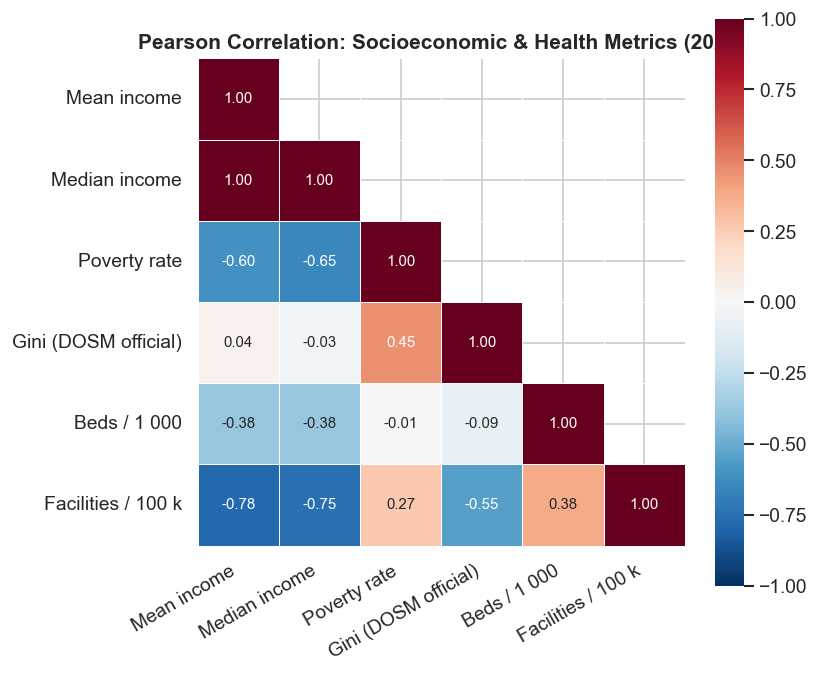

In [71]:
corr_labels = {
    "income_mean": "Mean income", "income_median": "Median income",
    "poverty_absolute": "Poverty rate", "gini": "Gini (DOSM official)",
    "beds_per_1000": "Beds / 1 000", "facilities_per_100k": "Facilities / 100 k",
}
corr_data   = ref[list(corr_labels)].rename(columns=corr_labels)
corr_matrix = corr_data.corr(method="pearson")
# Keep only lower triangle to avoid duplicated mirrored correlation values.
mask_arr    = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
mask_df     = pd.DataFrame(mask_arr, index=corr_matrix.index, columns=corr_matrix.columns)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, mask=mask_df, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 9})
style_ax(ax, "Pearson Correlation: Socioeconomic & Health Metrics (2022)")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
save_fig(fig, "fig7_correlation_heatmap")
plt.show()

Saved fig5_poverty_vs_facilities.png


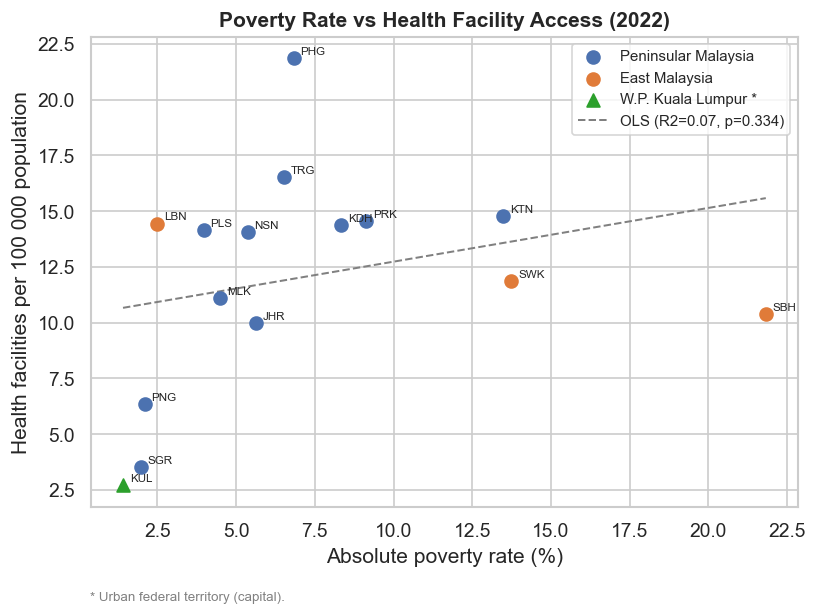

In [72]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(7, 5))
for label, mask_fn, color, marker in [
    ("Peninsular Malaysia", lambda r: (~r["state"].isin(EAST)) & (r["state"] != "W.P. Kuala Lumpur"), COLOR_MAP["west"], "o"),
    ("East Malaysia",       lambda r: r["state"].isin(EAST),                                          COLOR_MAP["east"], "o"),
    ("W.P. Kuala Lumpur *", lambda r: r["state"] == "W.P. Kuala Lumpur",                              COLOR_MAP["capital"], "^"),
]:
    group = ref[mask_fn(ref)]
    ax.scatter(group.poverty_absolute, group.facilities_per_100k,
               color=color, s=60, label=label, marker=marker, zorder=3)

for _, row in ref.iterrows():
    ax.annotate(row.state_code, (row.poverty_absolute, row.facilities_per_100k),
                fontsize=7, xytext=(4, 2), textcoords="offset points")

# Add OLS line to summarize the average linear association in the scatter plot.
m = ref.poverty_absolute.notna() & ref.facilities_per_100k.notna()
sl, ic, r, p, _ = stats.linregress(ref.loc[m, "poverty_absolute"], ref.loc[m, "facilities_per_100k"])
xl = pd.Series([ref.poverty_absolute.min(), ref.poverty_absolute.max()])
ax.plot(xl, sl * xl + ic, color="grey", linestyle="--", linewidth=1.2, label=f"OLS (R2={r**2:.2f}, p={p:.3f})")

style_ax(ax, "Poverty Rate vs Health Facility Access (2022)", "Absolute poverty rate (%)", "Health facilities per 100 000 population")
ax.legend(fontsize=9)
fig.text(0.12, -0.02, "* Urban federal territory (capital).", fontsize=8, color="grey")

plt.tight_layout()
save_fig(fig, "fig5_poverty_vs_facilities")
plt.show()

Saved fig4_income_vs_beds.png


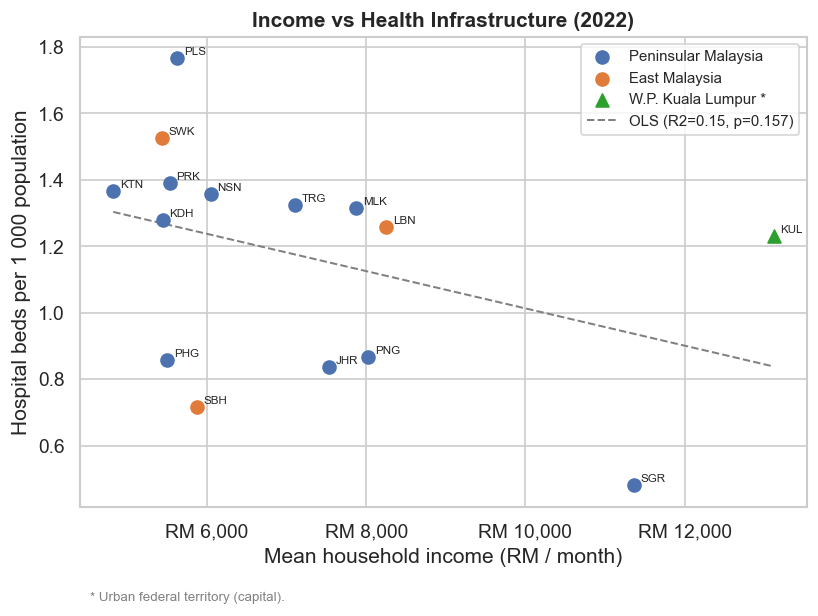

In [73]:
fig, ax = plt.subplots(figsize=(7, 5))
# Stratified scatter (region/capital groups) plus OLS trend for overall direction.
for label, mask_fn, color, marker in [
    ("Peninsular Malaysia", lambda r: (~r["state"].isin(EAST)) & (r["state"] != "W.P. Kuala Lumpur"), COLOR_MAP["west"], "o"),
    ("East Malaysia",       lambda r: r["state"].isin(EAST),                                          COLOR_MAP["east"], "o"),
    ("W.P. Kuala Lumpur *", lambda r: r["state"] == "W.P. Kuala Lumpur",                              COLOR_MAP["capital"], "^"),
]:
    group = ref[mask_fn(ref)]
    ax.scatter(group.income_mean, group.beds_per_1000,
               color=color, s=60, label=label, marker=marker, zorder=3)

for _, row in ref.iterrows():
    ax.annotate(row.state_code, (row.income_mean, row.beds_per_1000),
                fontsize=7, xytext=(4, 2), textcoords="offset points")

# Add OLS line to summarize the average linear association in the scatter plot.
m = ref.income_mean.notna() & ref.beds_per_1000.notna()
sl, ic, r, p, _ = stats.linregress(ref.loc[m, "income_mean"], ref.loc[m, "beds_per_1000"])
xl = pd.Series([ref.income_mean.min(), ref.income_mean.max()])
ax.plot(xl, sl * xl + ic, color="grey", linestyle="--", linewidth=1.2, label=f"OLS (R2={r**2:.2f}, p={p:.3f})")

style_ax(ax, "Income vs Health Infrastructure (2022)", "Mean household income (RM / month)",
         "Hospital beds per 1 000 population", rm_format="x")
ax.legend(fontsize=9)
fig.text(0.12, -0.02, "* Urban federal territory (capital).", fontsize=8, color="grey")

plt.tight_layout()
save_fig(fig, "fig4_income_vs_beds")
plt.show()

**Key finding:** Higher-income states have *fewer* public beds and facilities per capita (Spearman r = -0.53 for income vs beds, p = 0.041). This is explained by urban states relying on large private healthcare sectors not captured in MoH data. The significant Gini-facilities correlation (r = -0.55, p = 0.035) suggests states with lower inter-constituency income dispersion tend to receive more public health investment per capita.

---
## 4. Trends 2019-2024

> Did income and poverty improve across all states between survey years?

In [74]:
# Pivot to wide format (state x year) to compute change between survey waves.
trend = (
    se_main[se_main.year.isin([2019, 2022, 2024])]
    .pivot_table(index="state", columns="year", values="income_median")
    .round(0).astype(int)
)
trend["Delta 2019-2024"] = trend[2024] - trend[2019]
trend["% change"]        = ((trend[2024] / trend[2019] - 1) * 100).round(1)
trend = trend.sort_values("% change", ascending=False)

print("Median income (RM) by state:")
display(trend)

Median income (RM) by state:


year,2019,2022,2024,Delta 2019-2024,% change
state,,,,,
Selangor,7663,9146,9822,2159,28.2
Johor,5883,6215,7113,1230,20.9
Terengganu,5462,5788,6574,1112,20.4
Sarawak,3989,4316,4738,749,18.8
Pulau Pinang,6163,6426,7224,1061,17.2
Melaka,5909,6146,6894,985,16.7
Sabah,4104,4446,4704,600,14.6
Kelantan,3566,3698,4084,518,14.5
Negeri Sembilan,4604,4824,5144,540,11.7


In [75]:
# Same pivot approach for poverty, then sort by largest reduction (most improved first).
pov_trend = (
    se_main[se_main.year.isin([2019, 2022, 2024])]
    .pivot_table(index="state", columns="year", values="poverty_absolute")
    .round(2)
)
pov_trend["Delta 2019-2024"] = (pov_trend[2024] - pov_trend[2019]).round(2)
pov_trend = pov_trend.sort_values("Delta 2019-2024")

print("Poverty rate (%) by state â€” sorted by largest reduction:")
display(pov_trend)

Poverty rate (%) by state â€” sorted by largest reduction:


year,2019,2022,2024,Delta 2019-2024
state,,,,
Sabah,21.72,21.82,19.28,-2.44
Johor,4.62,5.63,3.09,-1.53
Terengganu,6.38,6.54,5.03,-1.35
Kelantan,12.82,13.49,11.53,-1.29
W.P. Labuan,3.10,2.50,2.00,-1.10
Sarawak,11.83,13.74,10.90,-0.93
Melaka,3.98,4.50,3.10,-0.88
Selangor,1.86,1.98,1.03,-0.83
Kedah,8.54,8.35,8.13,-0.41


In [76]:
# Unweighted state average per year (each state contributes equally).
national = (
    se_main.groupby("year")[["income_mean", "income_median", "poverty_absolute"]]
    .mean().round(2)
)
print("National averages (unweighted mean across states):")
display(national)

National averages (unweighted mean across states):


,income_mean,income_median,poverty_absolute
year,,,
2019,6918.11,5468.25,6.59
2022,7169.68,5747.49,7.16
2024,7682.35,6239.14,6.02


Saved fig6_income_trends.png


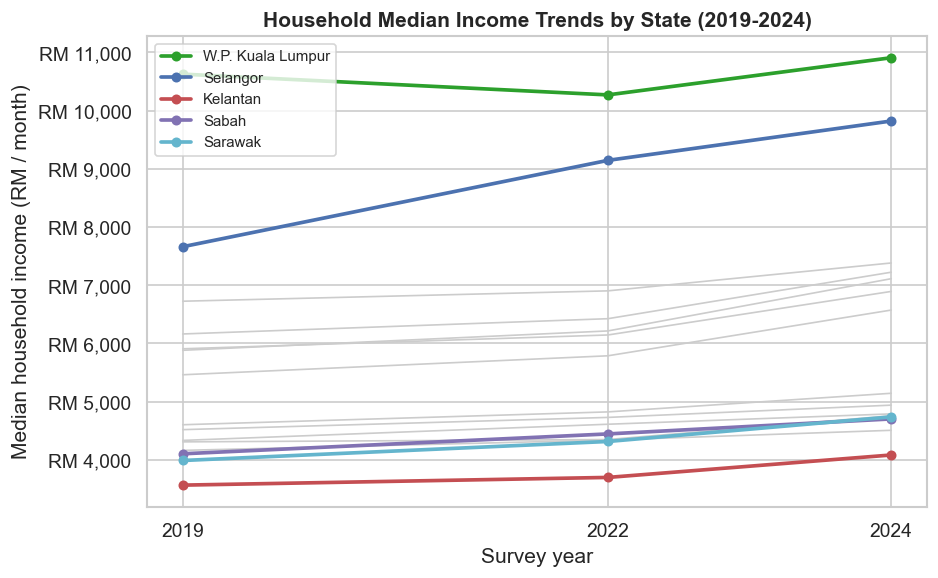

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))

# Show all states in muted lines, then overlay selected states as highlighted trajectories.
for state, grp in se_main.groupby("state"):
    if state not in HIGHLIGHT_STATES:
        ax.plot(grp.year, grp.income_median, color=COLOR_MAP["grey"], linewidth=1, zorder=1)

for state, color in zip(HIGHLIGHT_STATES, HIGHLIGHT_COLORS):
    grp = se_main[se_main.state == state].sort_values("year")
    ax.plot(grp.year, grp.income_median, color=color, linewidth=2.2,
            marker="o", markersize=5, label=state, zorder=3)

ax.set_xticks([2019, 2022, 2024])
style_ax(ax, "Household Median Income Trends by State (2019-2024)",
         "Survey year", "Median household income (RM / month)", rm_format="y")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
save_fig(fig, "fig6_income_trends")
plt.show()

**Key finding:** Median income rose in all 15 states 2019-2024. Selangor led (+28.2%), while W.P. Kuala Lumpur grew least (+2.7%) from a much higher base. Poverty fell in 12 of 15 states; Sabah had the largest absolute reduction (-2.4 pp) but remains the highest-poverty state at 19.3%.

---
## 5. Long-run History (1970-2024)

> How has household income and poverty evolved across five decades?

Uses `combined_state.csv` which merges DOSM HIES state-level aggregates (1970-2022) with constituency-derived figures (2019, 2022, 2024). No surveys were conducted in 2020-2021 (COVID-19). 2024 data is provisional.

In [78]:
# Extend the unweighted annual average approach across the full historical panel.
hist_main = combined[combined["territory_type"] != "admin"].copy()
national_hist = (
    hist_main.groupby("year")[["income_mean", "income_median", "poverty_absolute"]]
    .mean().round(2)
)
print("National averages (unweighted, excl. W.P. Putrajaya) â€” all survey years:")
display(national_hist)

National averages (unweighted, excl. W.P. Putrajaya) â€” all survey years:


,income_mean,income_median,poverty_absolute
year,,,
1970,244.91,NaN,52.93
1974,341.45,214.55,NaN
1976,505.14,317.64,45.74
1979,619.08,418.62,36.15
1984,1049.14,716.14,21.95
1987,1020.71,728.36,20.83
1989,1110.71,812.64,17.21
1992,1465.86,1054.21,13.74
1995,1826.57,1337.86,9.91


In [79]:
# Compare first vs latest available year to summarize long-run poverty reduction.
pov_hist = hist_main.pivot_table(index="state", columns="year", values="poverty_absolute")
avail = sorted(pov_hist.columns)
first_yr, last_yr = avail[0], avail[-1]

pov_reduction = pov_hist[[first_yr, last_yr]].copy()
pov_reduction.columns = [f"Poverty {first_yr} (%)", f"Poverty {last_yr} (%)"]
pov_reduction["Reduction (pp)"] = (
    pov_reduction[f"Poverty {first_yr} (%)"] - pov_reduction[f"Poverty {last_yr} (%)"]
).round(1)
pov_reduction = pov_reduction.sort_values("Reduction (pp)", ascending=False)

print(f"Poverty headcount ratio: {first_yr} to {last_yr}")
display(pov_reduction.round(2))

Poverty headcount ratio: 1970 to 2024


,Poverty 1970 (%),Poverty 2024 (%),Reduction (pp)
state,,,
Perlis,73.9,3.63,70.3
Kelantan,76.1,11.53,64.6
Terengganu,68.9,5.03,63.9
Kedah,63.2,8.13,55.1
Johor,45.7,3.09,42.6
Melaka,44.9,3.10,41.8
Pulau Pinang,43.7,2.01,41.7
Perak,48.6,8.37,40.2
Negeri Sembilan,44.8,4.92,39.9


Saved fig8_historical_income.png


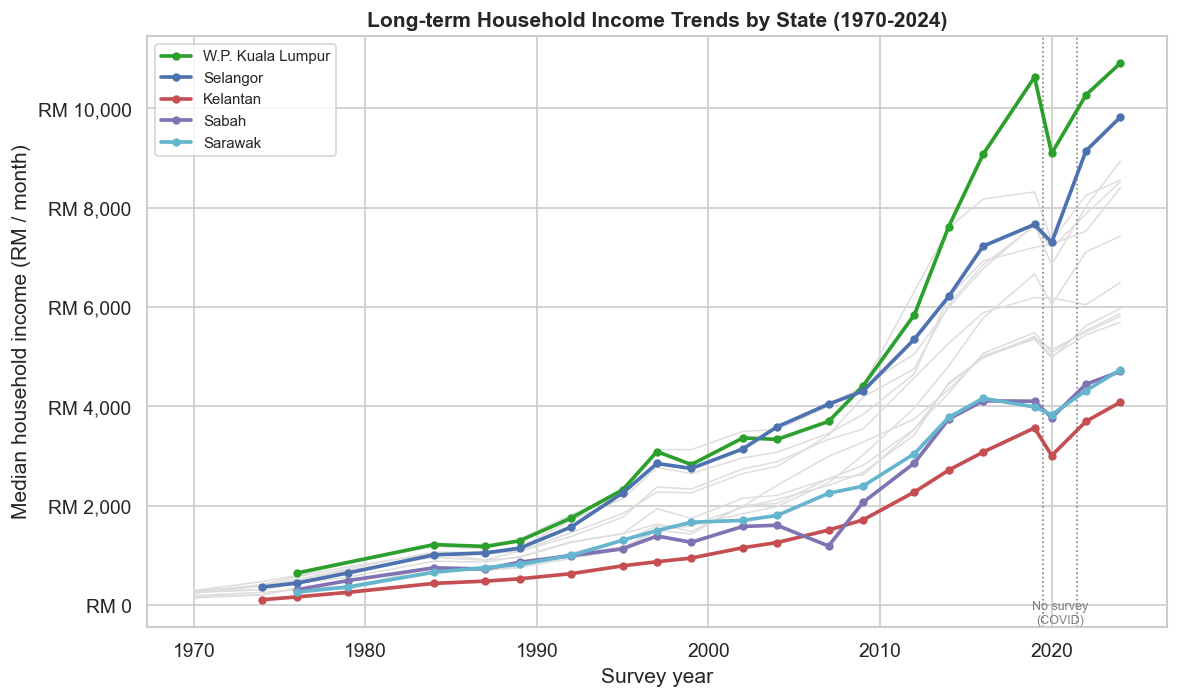

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

# Spaghetti plot of all states with highlighted focal states for readability.
for state, grp in hist_main.groupby("state"):
    if state not in HIGHLIGHT_STATES:
        ax.plot(grp.sort_values("year")["year"], grp.sort_values("year")["income_mean"],
                color="#dddddd", linewidth=0.9, zorder=1)

for state, color in zip(HIGHLIGHT_STATES, HIGHLIGHT_COLORS):
    grp = hist_main[hist_main.state == state].sort_values("year")
    ax.plot(grp["year"], grp["income_median"], color=color, linewidth=2.2,
            marker="o", markersize=4, label=state, zorder=3)

ax.axvline(x=2019.5, color="grey", linestyle=":", linewidth=1.0)
ax.axvline(x=2021.5, color="grey", linestyle=":", linewidth=1.0)
ax.text(2020.5, ax.get_ylim()[0], "No survey\n(COVID)", ha="center", fontsize=7.5, color="grey", va="bottom")

style_ax(ax, "Long-term Household Income Trends by State (1970-2024)",
         "Survey year", "Median household income (RM / month)", rm_format="y")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
save_fig(fig, "fig8_historical_income")
plt.show()

**Key finding:** Over five decades, national mean income grew ~31x in nominal terms and poverty fell from ~52.9% (1970) to ~6.0% (2024), one of the most sustained poverty-reduction trajectories in Southeast Asia. Perlis, Kelantan, and Terengganu started from the worst positions and have converged substantially toward the national average.

> **Caveats:** Income figures are nominal (not inflation-adjusted). Sabah, Sarawak, W.P. Kuala Lumpur, and W.P. Labuan lack 1970 poverty data. 2024 data is provisional.

---
## 6. Income Inequality Trend (Gini 1974–2022)

> How has the distribution of household income within each state changed over five decades?

Uses the official DOSM household Gini from `hh_inequality_state`, backfilled into `combined_state`. Gini measures inequality *within* each state (0 = perfect equality, 1 = maximum inequality).


In [81]:
gini_avail = hist_main[hist_main['gini'].notna()].copy()
nat_gini = gini_avail.groupby('year')['gini'].mean().reset_index()

print(f'State-years with official Gini: {len(gini_avail)}')
print('\nNational average Gini by survey year:')
display(nat_gini.set_index('year').T.round(3))

gini_pivot = gini_avail.pivot_table(index='state', columns='year', values='gini')
gini_delta = pd.DataFrame({
    'first_gini': gini_pivot.apply(lambda r: r.dropna().iloc[0], axis=1),
    'last_gini':  gini_pivot.apply(lambda r: r.dropna().iloc[-1], axis=1),
})
gini_delta['change'] = (gini_delta['last_gini'] - gini_delta['first_gini']).round(3)
print('\nGini change (latest vs earliest):')
display(gini_delta.sort_values('change'))


State-years with official Gini: 281

National average Gini by survey year:


year,1974,1976,1979,1984,1987,1989,1992,1995,1997,1999,2002,2004,2007,2009,2012,2014,2016,2019,2022,2024
gini,0.498,0.503,0.466,0.455,0.43,0.412,0.427,0.413,0.414,0.402,0.426,0.414,0.408,0.41,0.402,0.367,0.366,0.364,0.358,0.084



Gini change (latest vs earliest):


,first_gini,last_gini,change
state,,,
Kelantan,0.612,0.081878,-0.530
Pulau Pinang,0.597,0.084708,-0.512
Kedah,0.523,0.059273,-0.464
Melaka,0.506,0.055236,-0.451
Terengganu,0.502,0.057544,-0.444
Perlis,0.425,0.015784,-0.409
W.P. Labuan,0.388,0.000000,-0.388
Selangor,0.507,0.128389,-0.379
Perak,0.452,0.074342,-0.378


Saved fig_gini_trend.png


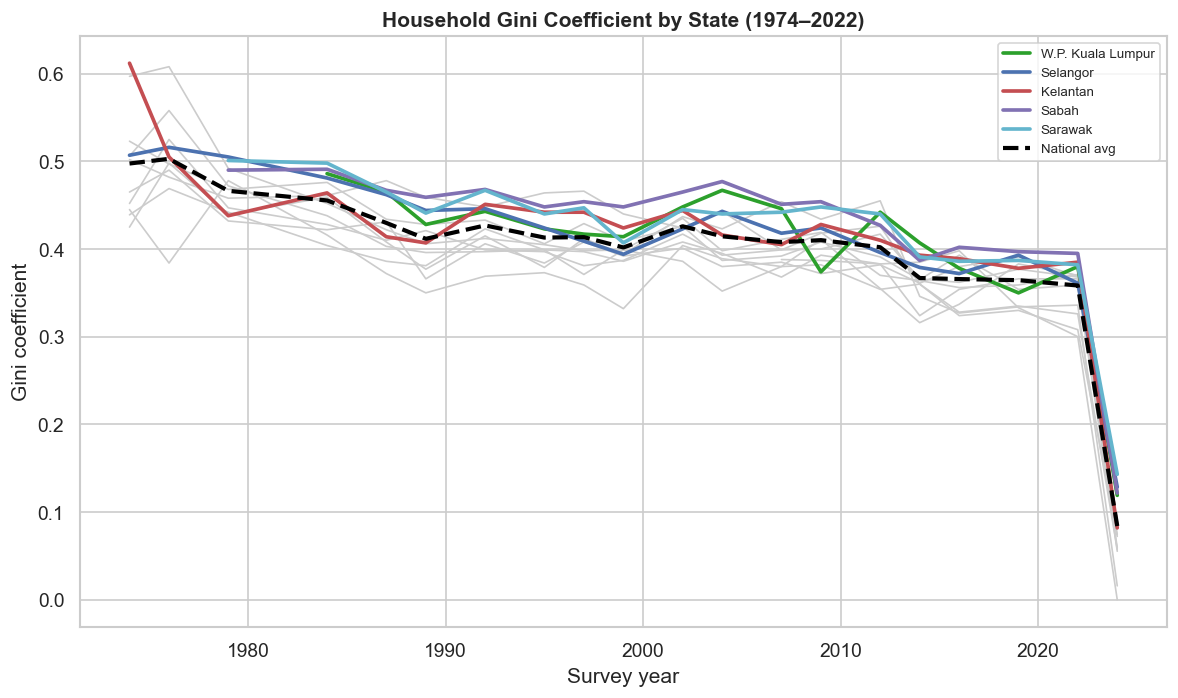

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))

for state in gini_avail['state'].unique():
    grp = gini_avail[gini_avail['state'] == state].sort_values('year')
    ax.plot(grp['year'], grp['gini'], color=COLOR_MAP['grey'], linewidth=1, zorder=1)

for state, color in zip(HIGHLIGHT_STATES, HIGHLIGHT_COLORS):
    grp = gini_avail[gini_avail['state'] == state].sort_values('year')
    if not grp.empty:
        ax.plot(grp['year'], grp['gini'], color=color, linewidth=2.2, label=state, zorder=2)

ax.plot(nat_gini['year'], nat_gini['gini'], color='black', linewidth=2.5,
        linestyle='--', label='National avg', zorder=3)

ax.legend(fontsize=8, loc='upper right')
style_ax(ax, 'Household Gini Coefficient by State (1974–2022)', 'Survey year', 'Gini coefficient')

plt.tight_layout()
save_fig(fig, 'fig_gini_trend')
plt.show()


> **Note:** A declining Gini indicates income distribution within the state is becoming more equal. These are DOSM household-level estimates and are directly comparable across survey years.


---
## 7. National CPI & Real Income

> Has income growth kept pace with inflation? How does purchasing power compare across states?

The national CPI (base 2010 = 100, DOSM ) deflates nominal median household income. **Real income = nominal / (CPI / 100)** expresses income in constant 2010 Ringgit, enabling fair comparison across years despite inflation.

Since all states share a single national deflator, CPI does not affect cross-state rankings within a year. Its value lies in cross-time comparisons: measuring whether real purchasing power has risen alongside nominal income growth.

**Coverage:** National CPI runs 1960–2025, covering the full historical series in .

In [83]:
# Sample national CPI at key years
key_years = [1970, 1980, 1990, 2000, 2010, 2015, 2019, 2022, 2024, 2025]
cpi_sample = cpi[cpi["year"].isin(key_years)].copy()
print("National CPI (overall, base 2010=100) at key years:")
display(cpi_sample.set_index("year")[["cpi_overall"]].round(1))
print(f"Full range: {cpi['year'].min()}-{cpi['year'].max()} ({len(cpi)} annual observations)")

National CPI (overall, base 2010=100) at key years:


,cpi_overall
year,
1970,23.4
1980,41.4
1990,56.8
2000,80.6
2010,100.0
2015,112.8
2019,121.5
2022,127.2
2024,132.8


Full range: 1960-2025 (66 annual observations)


In [84]:
# cpi_overall is already merged into combined_state via ETL — ref inherits it
ref_cpi = ref.dropna(subset=["income_median", "cpi_overall"]).copy()
ref_cpi["income_median_real"] = ref_cpi["income_median"] / (ref_cpi["cpi_overall"] / 100)

cpi_2022 = float(ref_cpi["cpi_overall"].iloc[0])
print(f"States with real income (2022): {len(ref_cpi)}/{len(ref)}")
print(f"National CPI (2022): {cpi_2022:.1f}  (same deflator applied to all states)")
print("Note: cross-state rankings are unchanged by deflation within a given year.")

comp = ref_cpi[["state", "income_median", "cpi_overall", "income_median_real"]].sort_values("income_median", ascending=False)
print("Nominal vs real median income (2022, RM in 2010 prices):")
display(comp.round(1))

States with real income (2022): 15/15
National CPI (2022): 127.2  (same deflator applied to all states)
Note: cross-state rankings are unchanged by deflation within a given year.
Nominal vs real median income (2022, RM in 2010 prices):


,state,income_median,cpi_overall,income_median_real
40,W.P. Kuala Lumpur,10271.1,127.2,8072.6
34,Selangor,9146.0,127.2,7188.4
43,W.P. Labuan,6904.0,127.2,5426.3
25,Pulau Pinang,6425.8,127.2,5050.4
1,Johor,6215.3,127.2,4885.0
10,Melaka,6146.0,127.2,4830.5
37,Terengganu,5788.2,127.2,4549.3
13,Negeri Sembilan,4824.2,127.2,3791.7
22,Perlis,4729.7,127.2,3717.3
16,Pahang,4612.3,127.2,3625.1


Saved fig_cpi_real_income.png


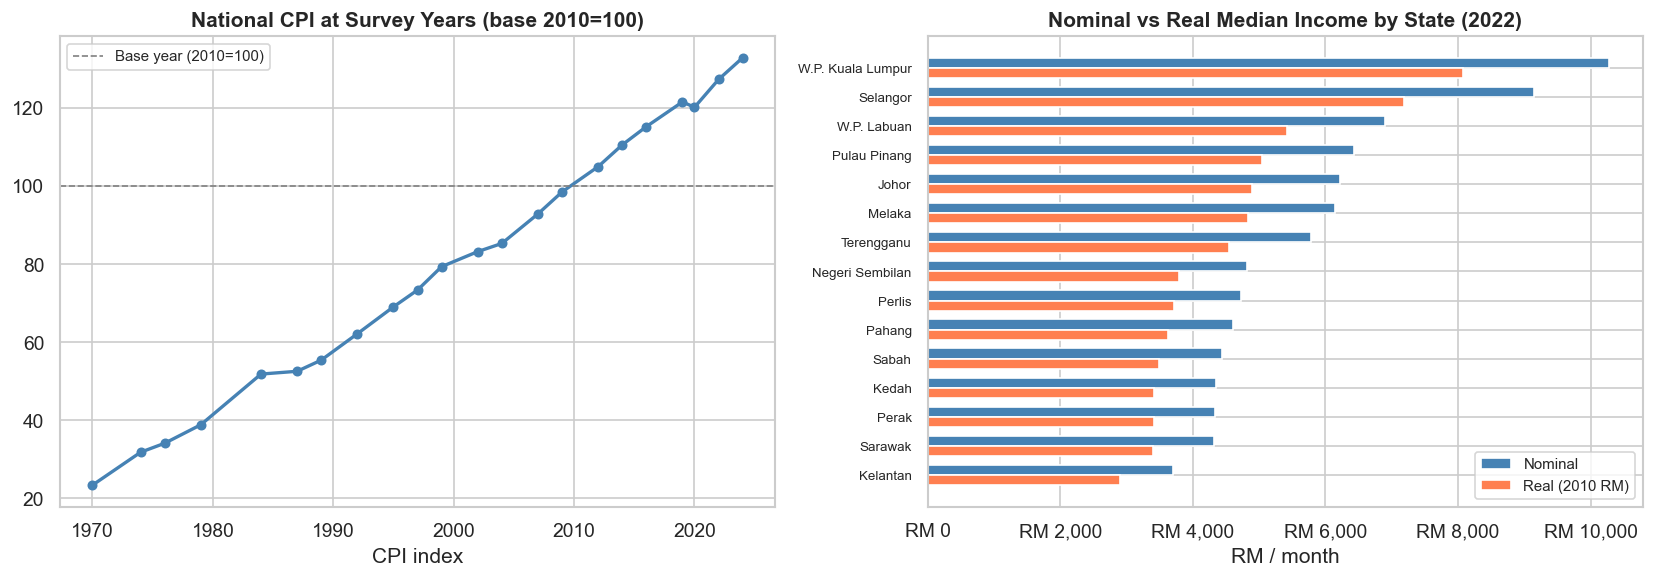

In [85]:
# --- Left: National CPI trend at survey years ---
survey_years_hist = sorted(hist_main["year"].unique())
cpi_trend = cpi[cpi["year"].isin(survey_years_hist)].sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cpi_trend["year"], cpi_trend["cpi_overall"],
             marker="o", color="steelblue", linewidth=2, markersize=5)
axes[0].axhline(100, color="grey", linestyle="--", linewidth=1, label="Base year (2010=100)")
axes[0].legend(fontsize=9)
style_ax(axes[0], "National CPI at Survey Years (base 2010=100)", "CPI index")

# --- Right: Nominal vs real income side-by-side (2022) ---
if ref_cpi["income_median_real"].notna().sum() > 0:
    comp2 = ref_cpi[["state", "income_median", "income_median_real"]].sort_values("income_median_real", ascending=True)
    y = range(len(comp2))
    h = 0.35
    axes[1].barh([i + h/2 for i in y], comp2["income_median"],       height=h, label="Nominal",       color="steelblue")
    axes[1].barh([i - h/2 for i in y], comp2["income_median_real"], height=h, label="Real (2010 RM)", color="coral")
    axes[1].set_yticks(list(y))
    axes[1].set_yticklabels(comp2["state"], fontsize=8)
    axes[1].legend(fontsize=9)
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"RM {x:,.0f}"))
    style_ax(axes[1], "Nominal vs Real Median Income by State (2022)", "RM / month")

plt.tight_layout()
save_fig(fig, "fig_cpi_real_income")
plt.show()

Saved fig_nominal_vs_real_income.png


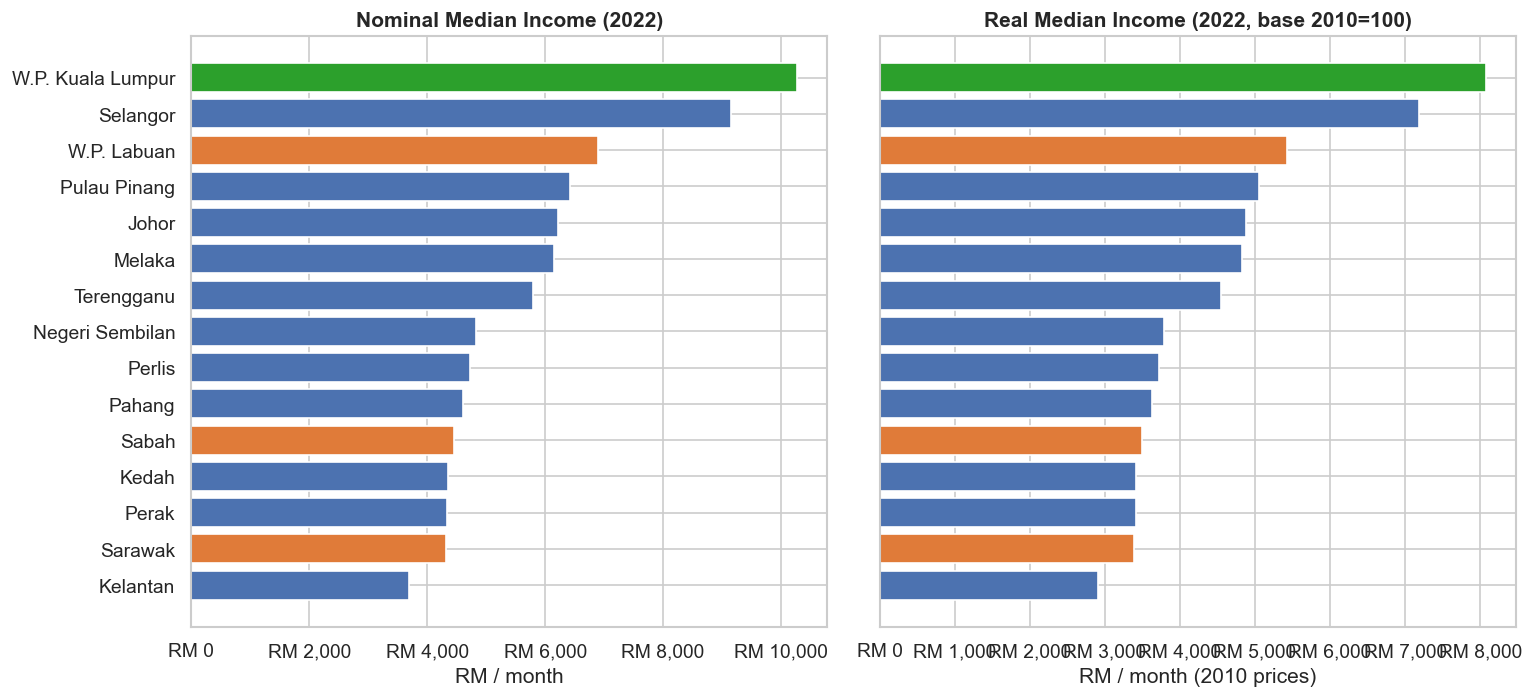

In [86]:
if ref_cpi['income_median_real'].notna().sum() > 0:
    comp = ref_cpi[['state', 'income_median', 'income_median_real', 'cpi_overall']].dropna()
    comp = comp.sort_values('income_median_real', ascending=True)
    colors = state_colors(comp['state'].tolist())

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

    axes[0].barh(comp['state'], comp['income_median'], color=colors)
    style_ax(axes[0], 'Nominal Median Income (2022)', 'RM / month', rm_format='x')

    axes[1].barh(comp['state'], comp['income_median_real'], color=colors)
    style_ax(axes[1], 'Real Median Income (2022, base 2010=100)',
             'RM / month (2010 prices)', rm_format='x')

    plt.tight_layout()
    save_fig(fig, 'fig_nominal_vs_real_income')
    plt.show()
else:
    print('Skipped: no CPI overlap with 2022. Re-run 01_acquire_data to fetch latest CPI.')


> **Interpretation:** The national CPI converts nominal income to constant 2010 Ringgit. Since the same deflator applies to all states in a given year, cross-state rankings are not affected. The real value does reveal purchasing power: at CPI ≈ 127 in 2022, incomes are worth roughly 79% of their nominal figure in 2010 prices. This also means the nominal ≈31× income growth since 1970 substantially overstates real gains.

> **Caveat:** A single national CPI assumes an identical consumption basket across all states. It does not capture urban–rural price differences, the spending patterns of lower-income households, or state-level cost-of-living variation.